In [1]:
import json
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt

In [2]:
# CONFIG
parent_dir = Path("model_outputs")
data_folder = "llmchess-testdifficulty-qwen25-7b-100"
INCLUDE_ERRORS = True

In [3]:
def plot_histogram(data: dict, title: str):
    """
    Reusable histogram function.
    - data: mapping from category (str) to value (float).
    - title: chart title.
    """
    fig, ax = plt.subplots()
    bars = ax.bar(
        list(data.keys()),
        list(data.values()),
        color='#FFA500',  # light orange
        width=0.8
    )
    ax.set_title(title)
    ax.set_xlabel('Category')
    ax.set_ylabel('Value')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    # annotate bars with value labels
    for bar in bars:
        h = bar.get_height()
        ax.annotate(
            f"{h:.2f}",
            xy=(bar.get_x() + bar.get_width() / 2, h),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom"
        )
    plt.show()

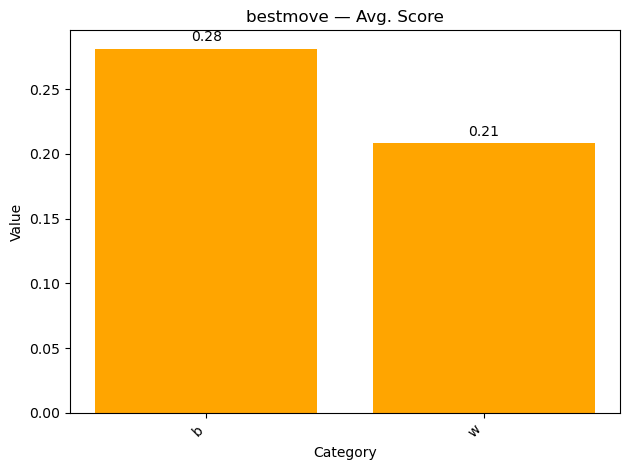

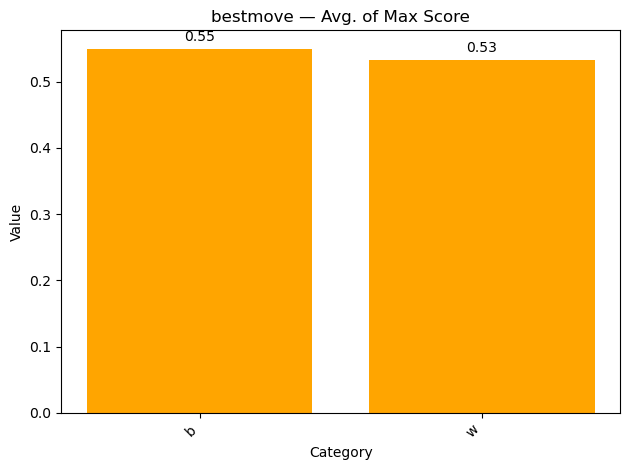

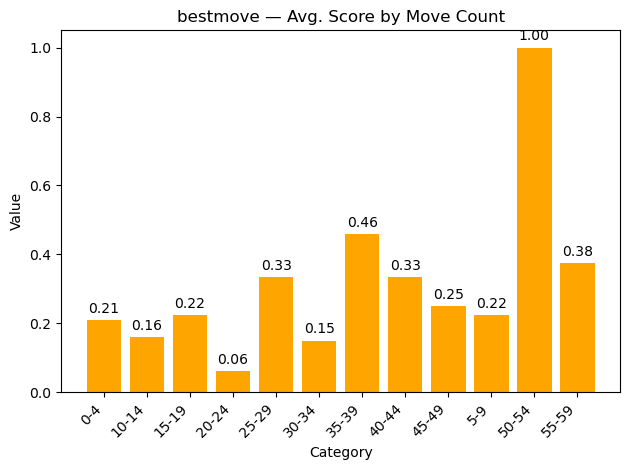

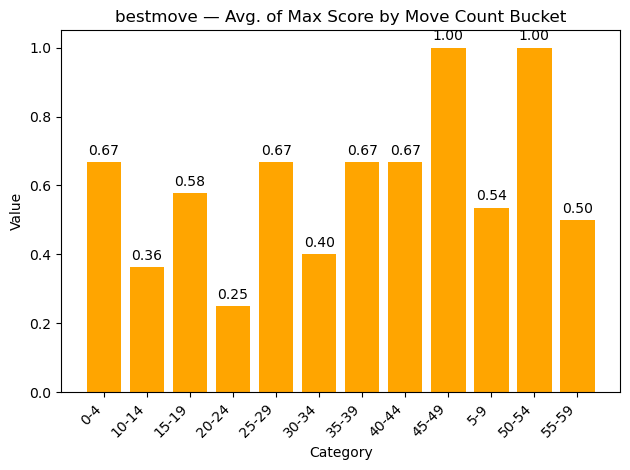

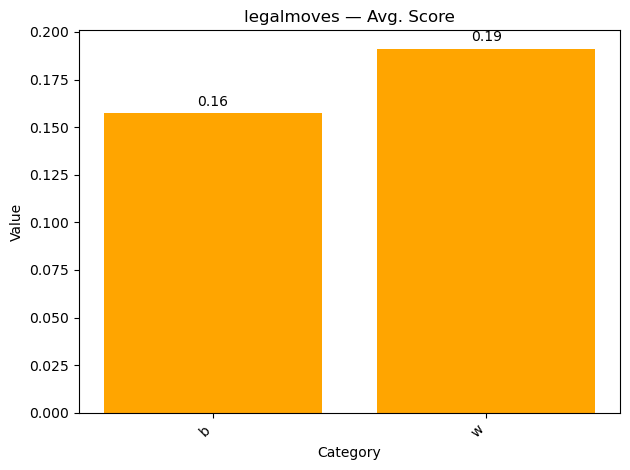

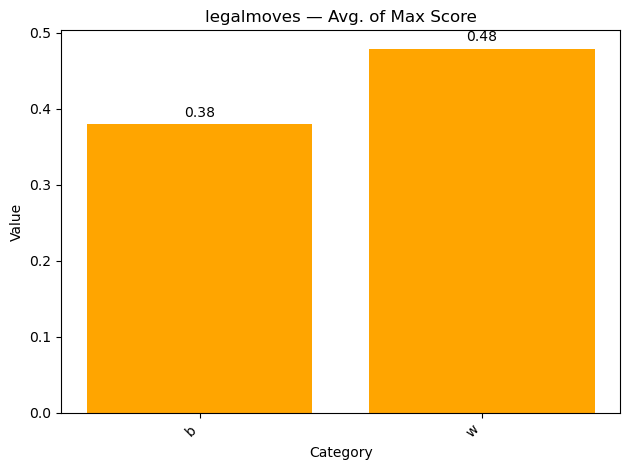

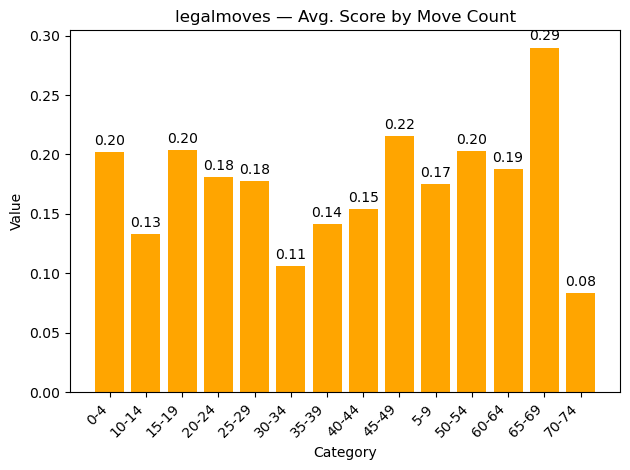

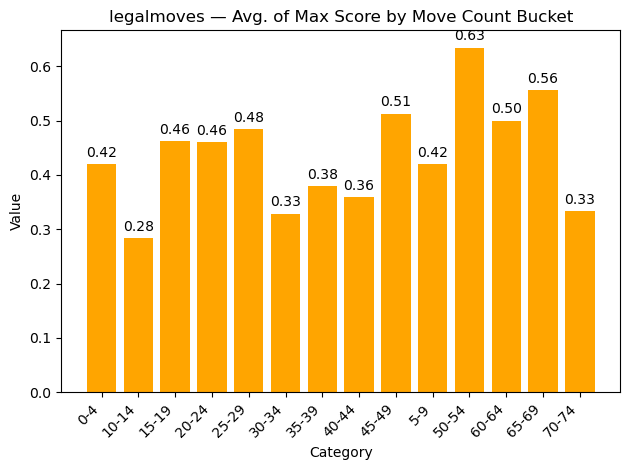

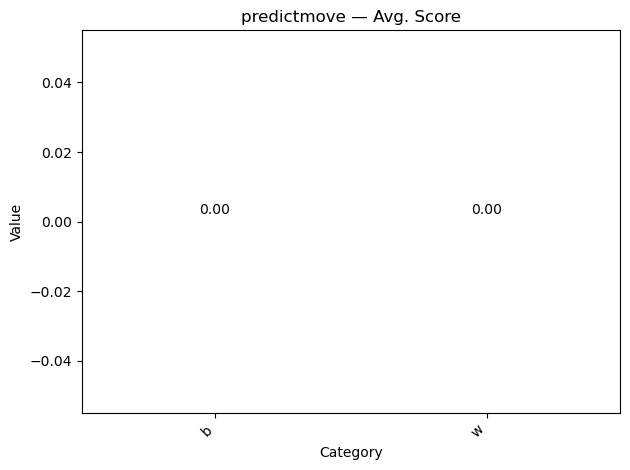

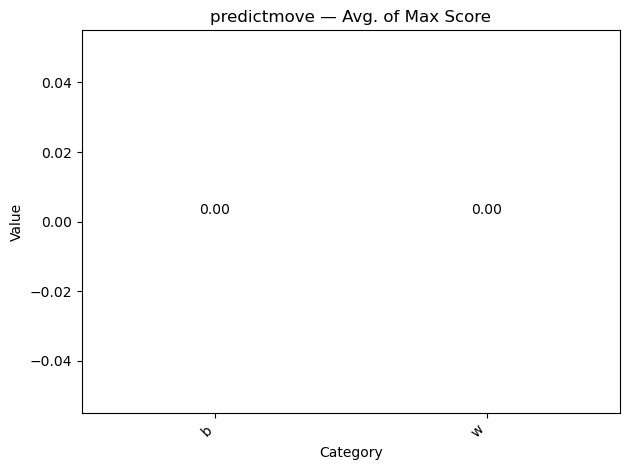

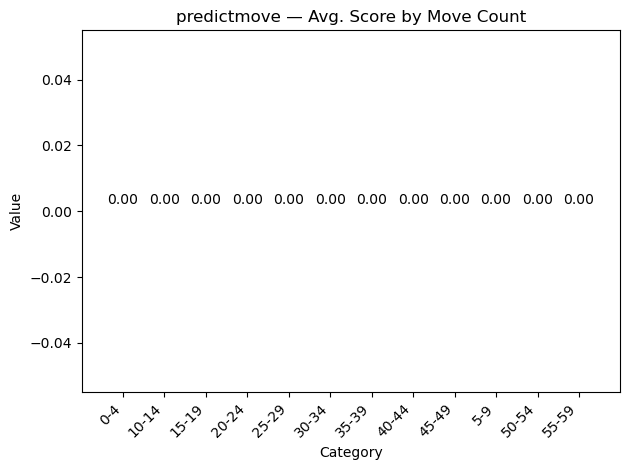

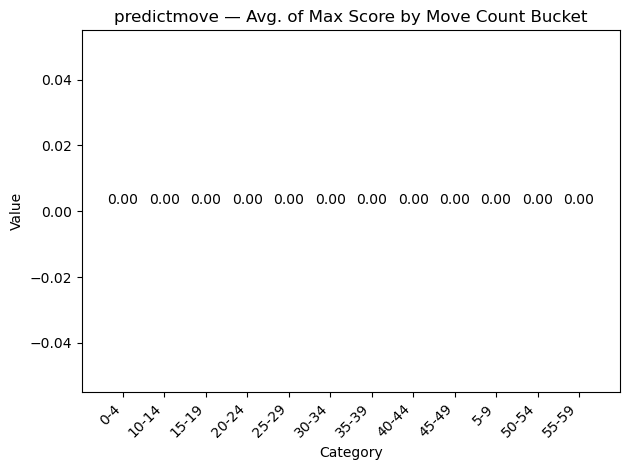

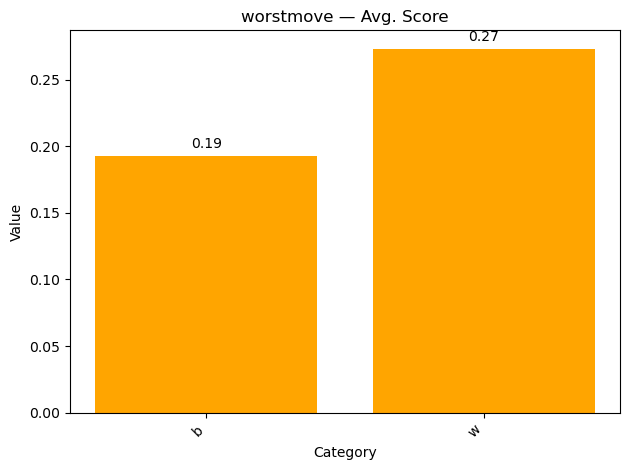

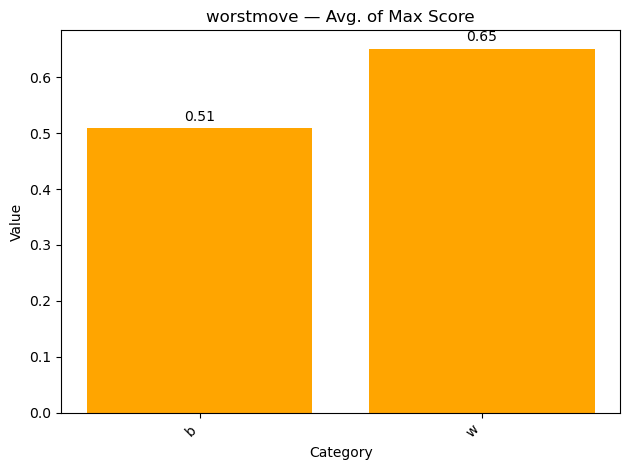

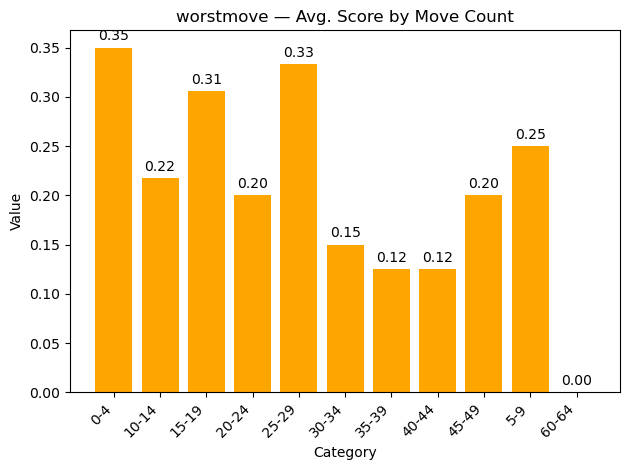

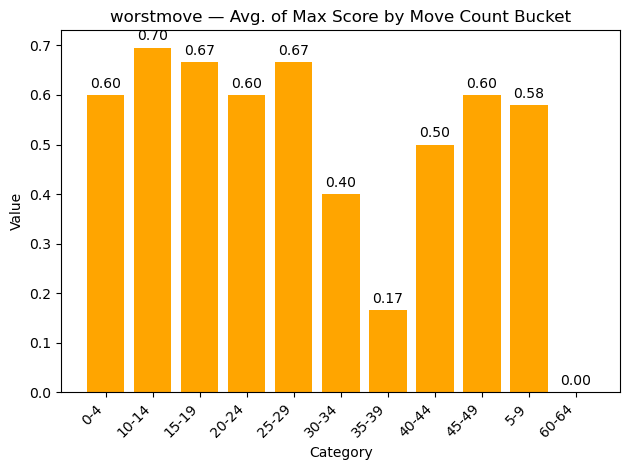

In [7]:
# Load JSONs and build DataFrames
dataframes = {}
for jf in (parent_dir / data_folder).glob("*.json"):
    with open(jf, encoding="utf-8") as fh:
        records = json.load(fh)

    rows = {}
    for board_id, rec in records.items():
        if INCLUDE_ERRORS:
            scores = [s if not isinstance(s, str) else 0 for s, _ in rec["score_answers"]]
        else:
            scores = [s for s, _ in rec["score_answers"] if isinstance(s, (int, float))]
        avg_score = sum(scores) / len(scores) if scores else 0.0
        max_score = max(scores) if scores else 0.0

        # parse FEN for color and move count
        fen = rec["info"]["board"]
        parts = fen.split(" ")
        color = parts[1]                   # 'w' or 'b'
        move_count = int(parts[-1])        # fullmove number

        rows[board_id] = {
            "average_score": avg_score,
            "max_score": max_score,
            "move_count": move_count,
            "color": color,
        }

    df = pd.DataFrame.from_dict(rows, orient="index")
    df.index.name = "board_id"
    dataframes[jf.stem[0:jf.stem.find('_')]] = df

# Plotting for each file
for name, df in dataframes.items():
    # 1) Avg & max by color
    avg_by_color = df.groupby("color")["average_score"].mean().to_dict()
    plot_histogram(avg_by_color, f"{name} — Avg. Score")

    max_by_color = df.groupby("color")["max_score"].mean().to_dict()
    plot_histogram(max_by_color, f"{name} — Avg. of Max Score")

    # 2) Avg & max by move_count buckets of size 5
    df["bucket"] = (df["move_count"] // 5) * 5
    df["bucket_label"] = df["bucket"].astype(str) + "-" + (df["bucket"] + 4).astype(str)

    avg_by_bucket = df.groupby("bucket_label")["average_score"].mean().to_dict()
    plot_histogram(avg_by_bucket, f"{name} — Avg. Score by Move Count")

    max_by_bucket = df.groupby("bucket_label")["max_score"].mean().to_dict()
    plot_histogram(max_by_bucket, f"{name} — Avg. of Max Score by Move Count Bucket")